# TikZ class image matrices

This notebook reads final Parquet shards directly with PyArrow and creates one image matrix for every class in both the `train` and `benchmark` splits.

The grid size is configurable. For example:

```python
GRID_ROWS = 4
GRID_COLS = 5
```

This displays 20 images per class and split without creating a Hugging Face Arrow cache.


In [28]:
from pathlib import Path

# Root folder containing the final Parquet shards.
DATA_DIR = Path("../dataset")

# Image matrix configuration.
GRID_ROWS = 4
GRID_COLS = 5
FIGURE_WIDTH_PER_IMAGE = 3.0
FIGURE_HEIGHT_PER_IMAGE = 3.0

RANDOM_SEED = 42

# None displays every class.
# Example: ["class_1", "class_4"]
SELECTED_CLASSES = None

IMAGE_COLUMN = "input_image"

# Optional title shown above every image.
# Supported values: None, "source", "type", "index"
IMAGE_TITLE = None

# Used when file paths do not identify the split.
SPLIT_COLUMN_CANDIDATES = (
    "split",
    "dataset",
    "dataset_name",
    "type",
)

TRAIN_VALUES = {
    "train",
    "datikz",
    "datikz-v4",
}

BENCHMARK_VALUES = {
    "benchmark",
    "bench",
}

BATCH_SIZE = 256


In [29]:
from collections import Counter, defaultdict
from io import BytesIO
import random

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display
from PIL import Image as PILImage


## Discover files and splits

In [30]:
def discover_parquet_files(directory: Path) -> list[Path]:
    files = sorted(directory.rglob("*.parquet"))

    if not files:
        raise FileNotFoundError(
            f"No Parquet files found in {directory}"
        )

    return files


def split_from_path(path: Path) -> str | None:
    text = str(path).lower()

    if "benchmark" in text:
        return "benchmark"

    if "train" in text or "datikz" in text:
        return "train"

    return None


ALL_FILES = discover_parquet_files(DATA_DIR)

FILES_BY_PATH = {
    "train": [],
    "benchmark": [],
    "unknown": [],
}

for path in ALL_FILES:
    detected_split = split_from_path(path)

    if detected_split is None:
        FILES_BY_PATH["unknown"].append(path)
    else:
        FILES_BY_PATH[detected_split].append(path)

for split, files in FILES_BY_PATH.items():
    size_gib = sum(path.stat().st_size for path in files) / 1024**3
    print(f"{split}: {len(files)} files, {size_gib:.2f} GiB")


train: 243 files, 23.40 GiB
benchmark: 28 files, 2.63 GiB
unknown: 0 files, 0.00 GiB


In [31]:
def choose_split_column(files: list[Path]) -> str | None:
    common_columns = None

    for path in files:
        columns = set(pq.ParquetFile(path).schema_arrow.names)

        if common_columns is None:
            common_columns = columns
        else:
            common_columns &= columns

    common_columns = common_columns or set()

    for candidate in SPLIT_COLUMN_CANDIDATES:
        if candidate in common_columns:
            return candidate

    return None


PATH_SPLITS_AVAILABLE = bool(
    FILES_BY_PATH["train"]
    and FILES_BY_PATH["benchmark"]
)

if PATH_SPLITS_AVAILABLE:
    SPLIT_MODE = "path"
    SPLIT_COLUMN = None
    SPLIT_FILES = {
        "train": FILES_BY_PATH["train"],
        "benchmark": FILES_BY_PATH["benchmark"],
    }
else:
    SPLIT_MODE = "column"
    SPLIT_COLUMN = choose_split_column(ALL_FILES)

    if SPLIT_COLUMN is None:
        raise ValueError(
            "Could not identify train and benchmark. "
            "Use filenames/subfolders containing 'train' and "
            "'benchmark', or provide a split-like column."
        )

    SPLIT_FILES = {
        "train": ALL_FILES,
        "benchmark": ALL_FILES,
    }

print(f"Split mode: {SPLIT_MODE}")
print(f"Split column: {SPLIT_COLUMN}")


Split mode: path
Split column: None


## Validate the final dataset

In [32]:
def normalized_text(value) -> str:
    return str(value or "").strip().lower()


def row_belongs_to_split(row: dict, split: str) -> bool:
    if SPLIT_MODE == "path":
        return True

    value = normalized_text(row.get(SPLIT_COLUMN))

    if split == "train":
        return value in TRAIN_VALUES

    return value in BENCHMARK_VALUES


def validate_schema(files: list[Path]) -> None:
    required = {
        "class",
        IMAGE_COLUMN,
    }

    for path in files:
        columns = set(pq.ParquetFile(path).schema_arrow.names)
        missing = required - columns

        if missing:
            raise ValueError(
                f"Missing final columns {sorted(missing)} in {path}. "
                "This is probably a staging Parquet file."
            )


validate_schema(ALL_FILES)

IMAGES_PER_CLASS = GRID_ROWS * GRID_COLS

if IMAGES_PER_CLASS <= 0:
    raise ValueError("GRID_ROWS and GRID_COLS must be positive.")

print(f"Images per class and split: {IMAGES_PER_CLASS}")


Images per class and split: 20


## Class distribution

In [33]:
def count_classes(
    files: list[Path],
    split: str,
) -> Counter:
    counts = Counter()
    columns = ["class"]

    if SPLIT_MODE == "column":
        columns.append(SPLIT_COLUMN)

    for path in files:
        parquet = pq.ParquetFile(path)

        for batch in parquet.iter_batches(
            columns=columns,
            batch_size=16_384,
        ):
            for row in batch.to_pylist():
                if not row_belongs_to_split(row, split):
                    continue

                class_name = row.get("class")

                if class_name is not None:
                    counts[class_name] += 1

    return counts


class_counts = {
    split: count_classes(files, split)
    for split, files in SPLIT_FILES.items()
}

distribution_rows = []

for split, counts in class_counts.items():
    total = sum(counts.values())

    for class_name, count in sorted(counts.items()):
        distribution_rows.append(
            {
                "split": split,
                "class": class_name,
                "count": count,
                "fraction": count / total if total else 0.0,
            }
        )

distribution = pd.DataFrame(distribution_rows)
display(distribution)


,split,class,count,fraction
0,train,class_1,158972,0.395686
1,train,class_2,82406,0.205111
2,train,class_3,104128,0.259178
3,train,class_4,56257,0.140025
4,benchmark,class_1,14822,0.364535
5,benchmark,class_2,10782,0.265175
6,benchmark,class_3,9988,0.245647
7,benchmark,class_4,5068,0.124643


## Load image examples

In [34]:
def classes_to_show(split: str) -> list[str]:
    available = sorted(class_counts[split])

    if SELECTED_CLASSES is None:
        return available

    return [
        class_name
        for class_name in SELECTED_CLASSES
        if class_name in available
    ]


def load_image_examples(
    files: list[Path],
    split: str,
    wanted_classes: list[str],
    images_per_class: int,
    seed: int,
) -> dict[str, list[dict]]:
    wanted_columns = [
        IMAGE_COLUMN,
        "class",
        "source",
        "type",
    ]

    if SPLIT_MODE == "column":
        wanted_columns.append(SPLIT_COLUMN)

    selected = defaultdict(list)
    shuffled_files = list(files)
    random.Random(seed).shuffle(shuffled_files)

    for file_index, path in enumerate(shuffled_files):
        parquet = pq.ParquetFile(path)
        available_columns = set(parquet.schema_arrow.names)

        read_columns = [
            column
            for column in wanted_columns
            if column in available_columns
        ]

        for batch_index, batch in enumerate(
            parquet.iter_batches(
                columns=read_columns,
                batch_size=BATCH_SIZE,
            )
        ):
            rows = batch.to_pylist()

            batch_seed = seed + file_index * 100_000 + batch_index
            random.Random(batch_seed).shuffle(rows)

            for row in rows:
                if not row_belongs_to_split(row, split):
                    continue

                class_name = row.get("class")

                if class_name not in wanted_classes:
                    continue

                if len(selected[class_name]) >= images_per_class:
                    continue

                selected[class_name].append(row)

            complete = all(
                len(selected[class_name]) >= images_per_class
                for class_name in wanted_classes
            )

            if complete:
                return dict(selected)

    return dict(selected)


image_examples = {
    split: load_image_examples(
        files=files,
        split=split,
        wanted_classes=classes_to_show(split),
        images_per_class=IMAGES_PER_CLASS,
        seed=RANDOM_SEED,
    )
    for split, files in SPLIT_FILES.items()
}

for split, class_examples in image_examples.items():
    print(f"\n{split}")

    for class_name in classes_to_show(split):
        count = len(class_examples.get(class_name, []))
        print(
            f"  {class_name}: {count}/{IMAGES_PER_CLASS} images"
        )



train
  class_1: 20/20 images
  class_2: 20/20 images
  class_3: 20/20 images
  class_4: 20/20 images

benchmark
  class_1: 20/20 images
  class_2: 20/20 images
  class_3: 20/20 images
  class_4: 20/20 images


## Image conversion and matrix display

In [35]:
def to_pil(value) -> PILImage.Image:
    if isinstance(value, PILImage.Image):
        return value.convert("RGB")

    if isinstance(value, dict):
        if value.get("bytes") is not None:
            return PILImage.open(
                BytesIO(value["bytes"])
            ).convert("RGB")

        if value.get("path"):
            return PILImage.open(
                value["path"]
            ).convert("RGB")

    if isinstance(value, (bytes, bytearray, memoryview)):
        return PILImage.open(
            BytesIO(bytes(value))
        ).convert("RGB")

    return PILImage.open(value).convert("RGB")


def image_title(row: dict, index: int) -> str:
    if IMAGE_TITLE == "source":
        return str(row.get("source", ""))

    if IMAGE_TITLE == "type":
        return str(row.get("type", ""))

    if IMAGE_TITLE == "index":
        return str(index + 1)

    return ""


def show_class_matrix(
    split: str,
    class_name: str,
) -> None:
    rows = image_examples[split].get(class_name, [])

    figure, axes = plt.subplots(
        GRID_ROWS,
        GRID_COLS,
        figsize=(
            GRID_COLS * FIGURE_WIDTH_PER_IMAGE,
            GRID_ROWS * FIGURE_HEIGHT_PER_IMAGE,
        ),
        squeeze=False,
    )

    figure.suptitle(
        f"{split} — {class_name} "
        f"({len(rows)}/{IMAGES_PER_CLASS} images)",
        fontsize=16,
    )

    flat_axes = axes.ravel()

    for index, axis in enumerate(flat_axes):
        axis.axis("off")

        if index >= len(rows):
            continue

        try:
            image = to_pil(rows[index][IMAGE_COLUMN])
            axis.imshow(image)
        except Exception as error:
            axis.text(
                0.5,
                0.5,
                f"Image error\n{type(error).__name__}",
                ha="center",
                va="center",
            )

        title = image_title(rows[index], index)

        if title:
            axis.set_title(title, fontsize=9)

    plt.tight_layout()
    plt.show()


def show_split_matrices(split: str) -> None:
    for class_name in classes_to_show(split):
        show_class_matrix(split, class_name)


## Train matrices

This creates one matrix for every selected class in the `train` split.


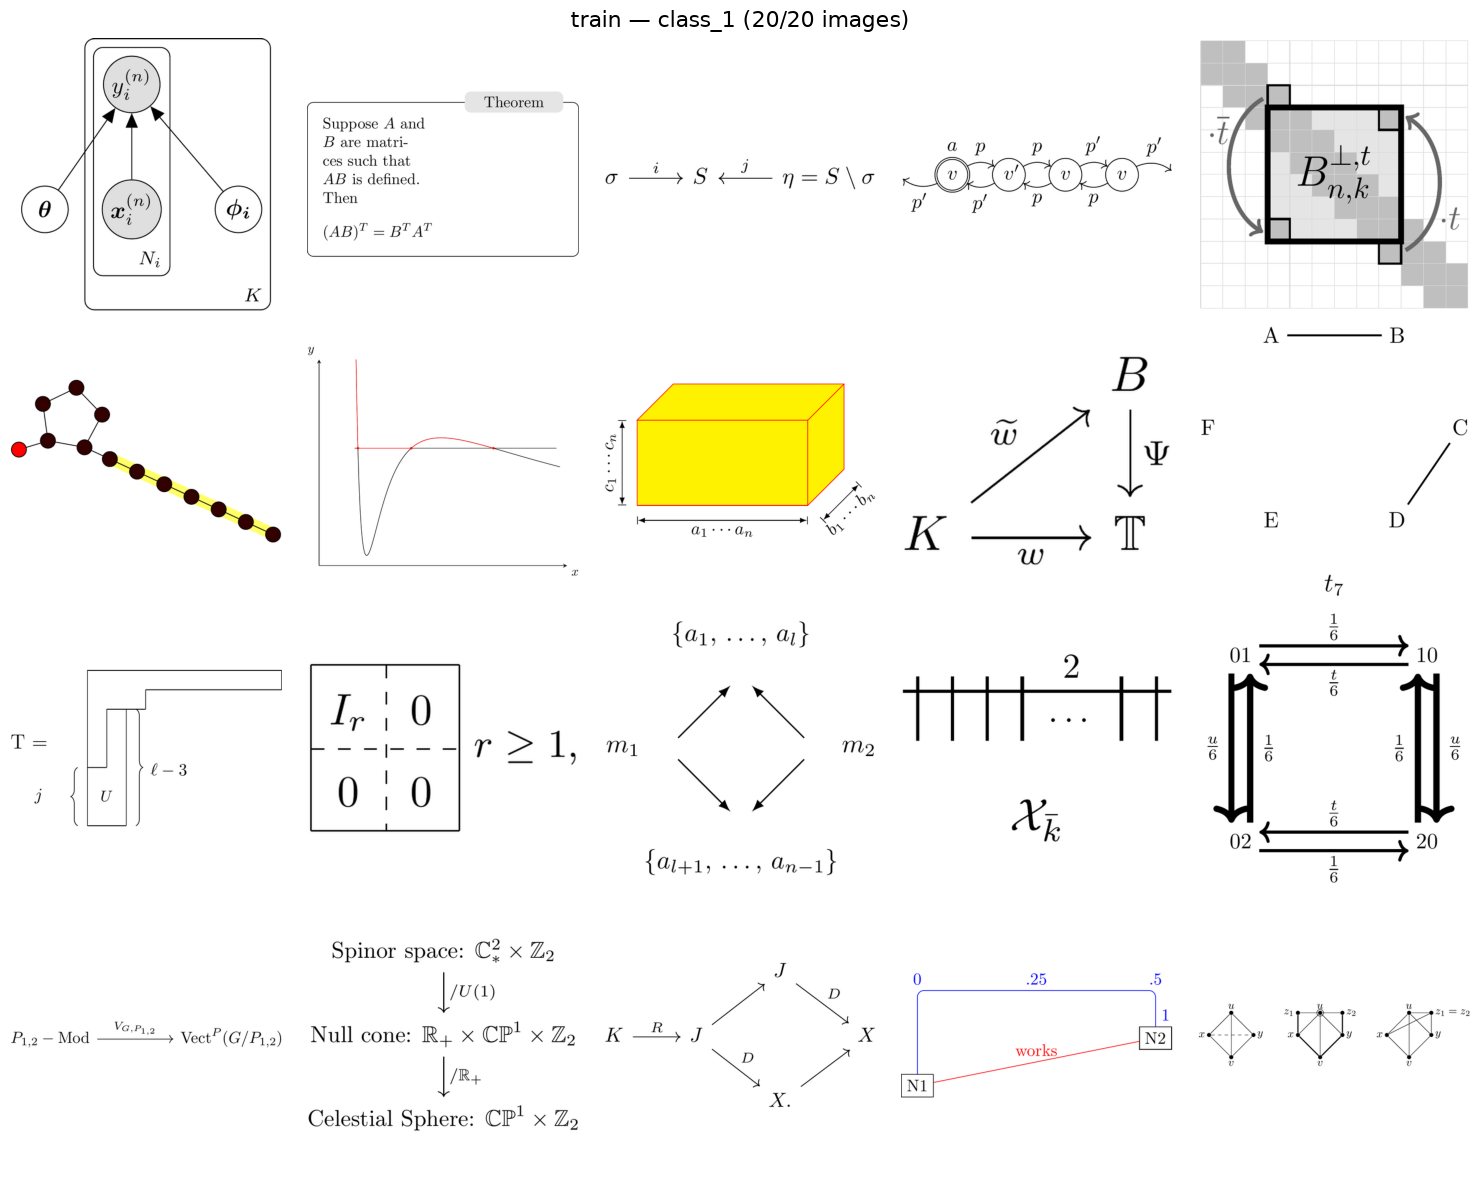

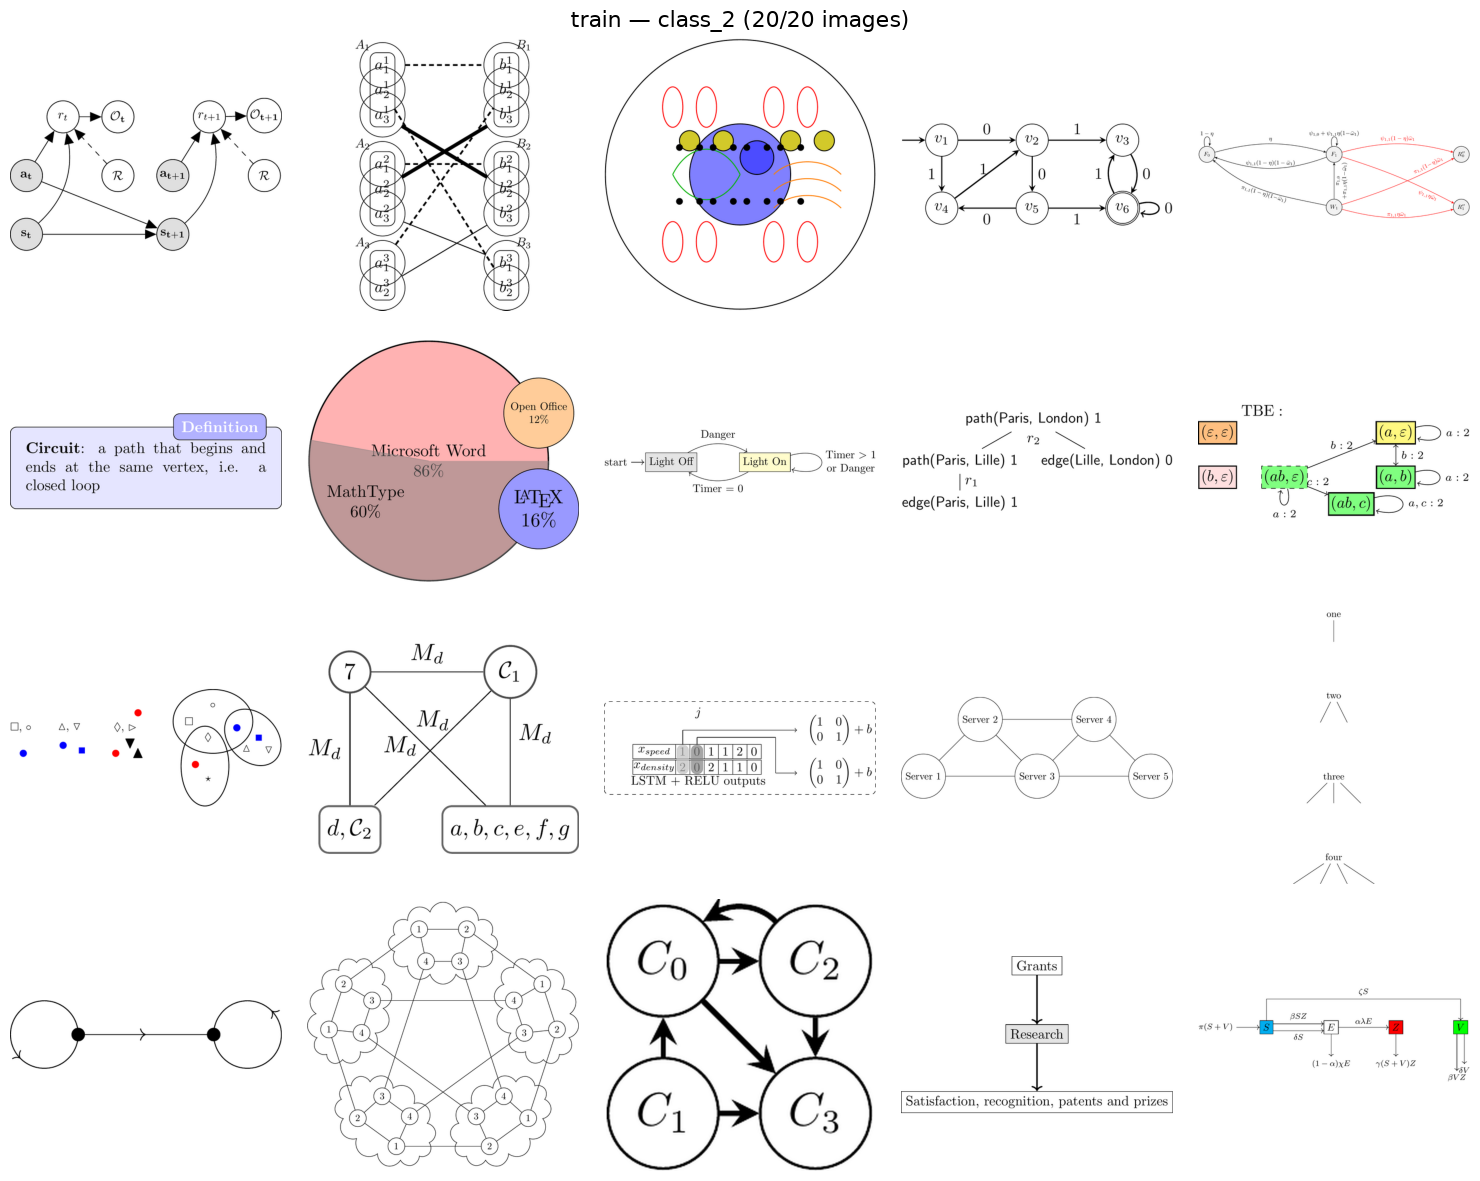

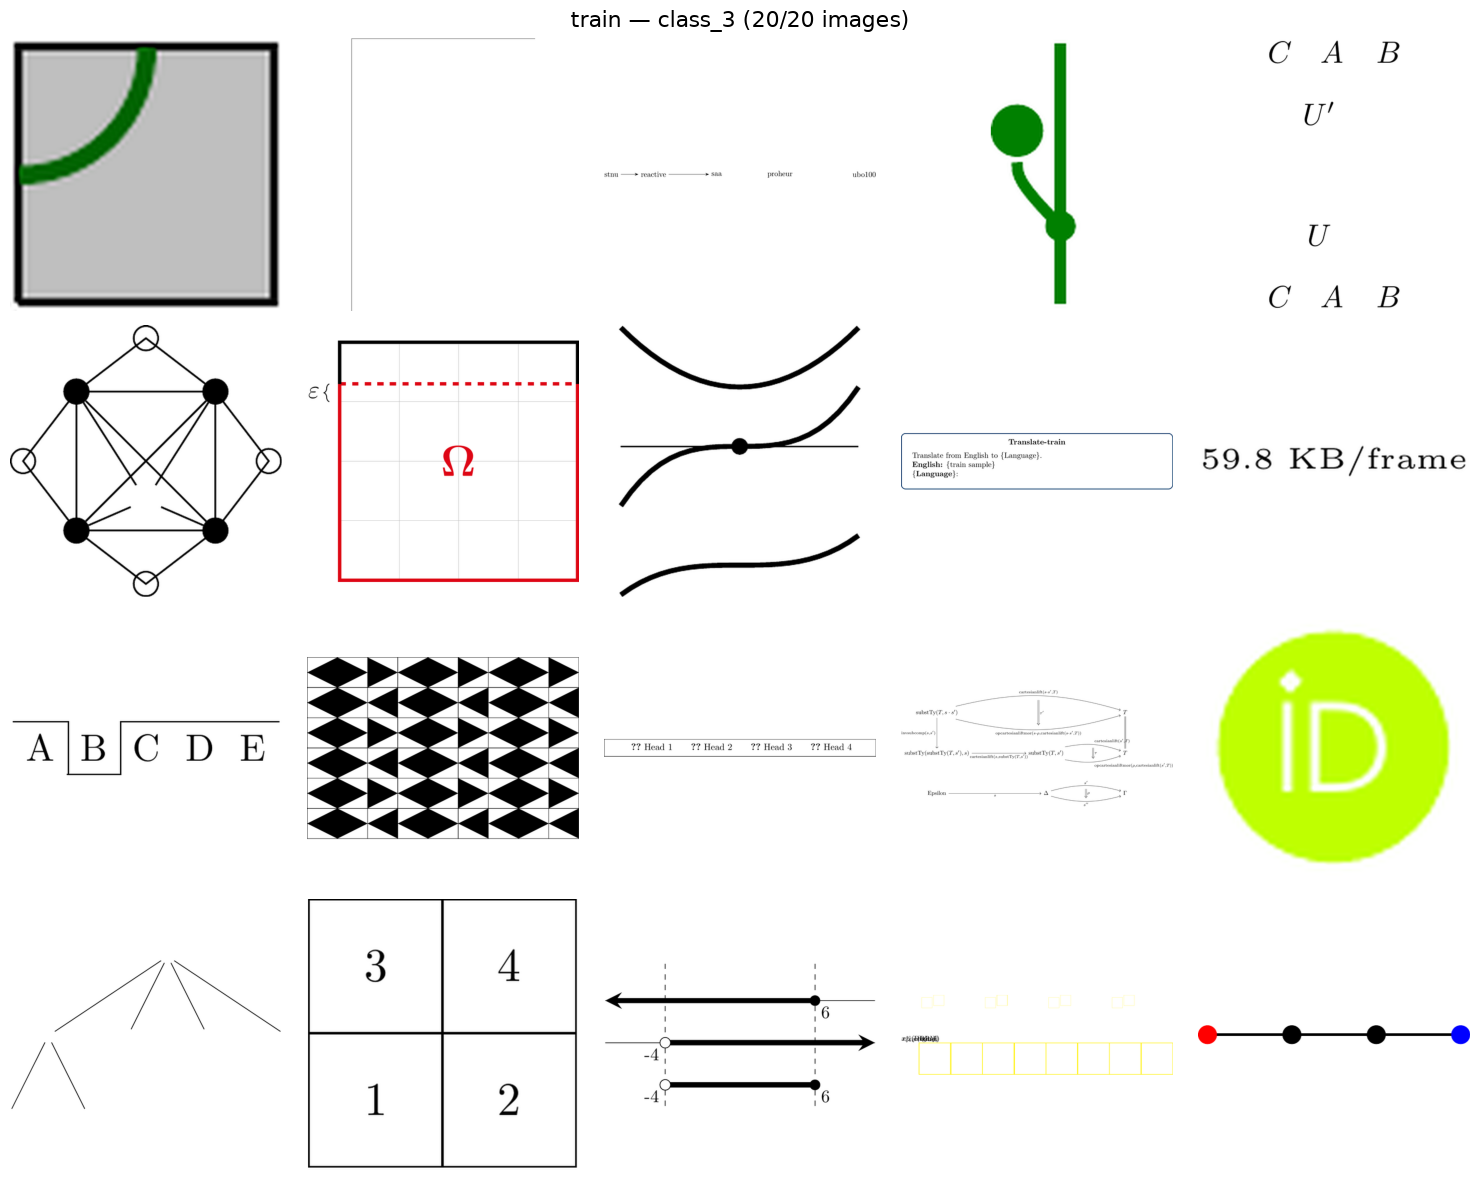

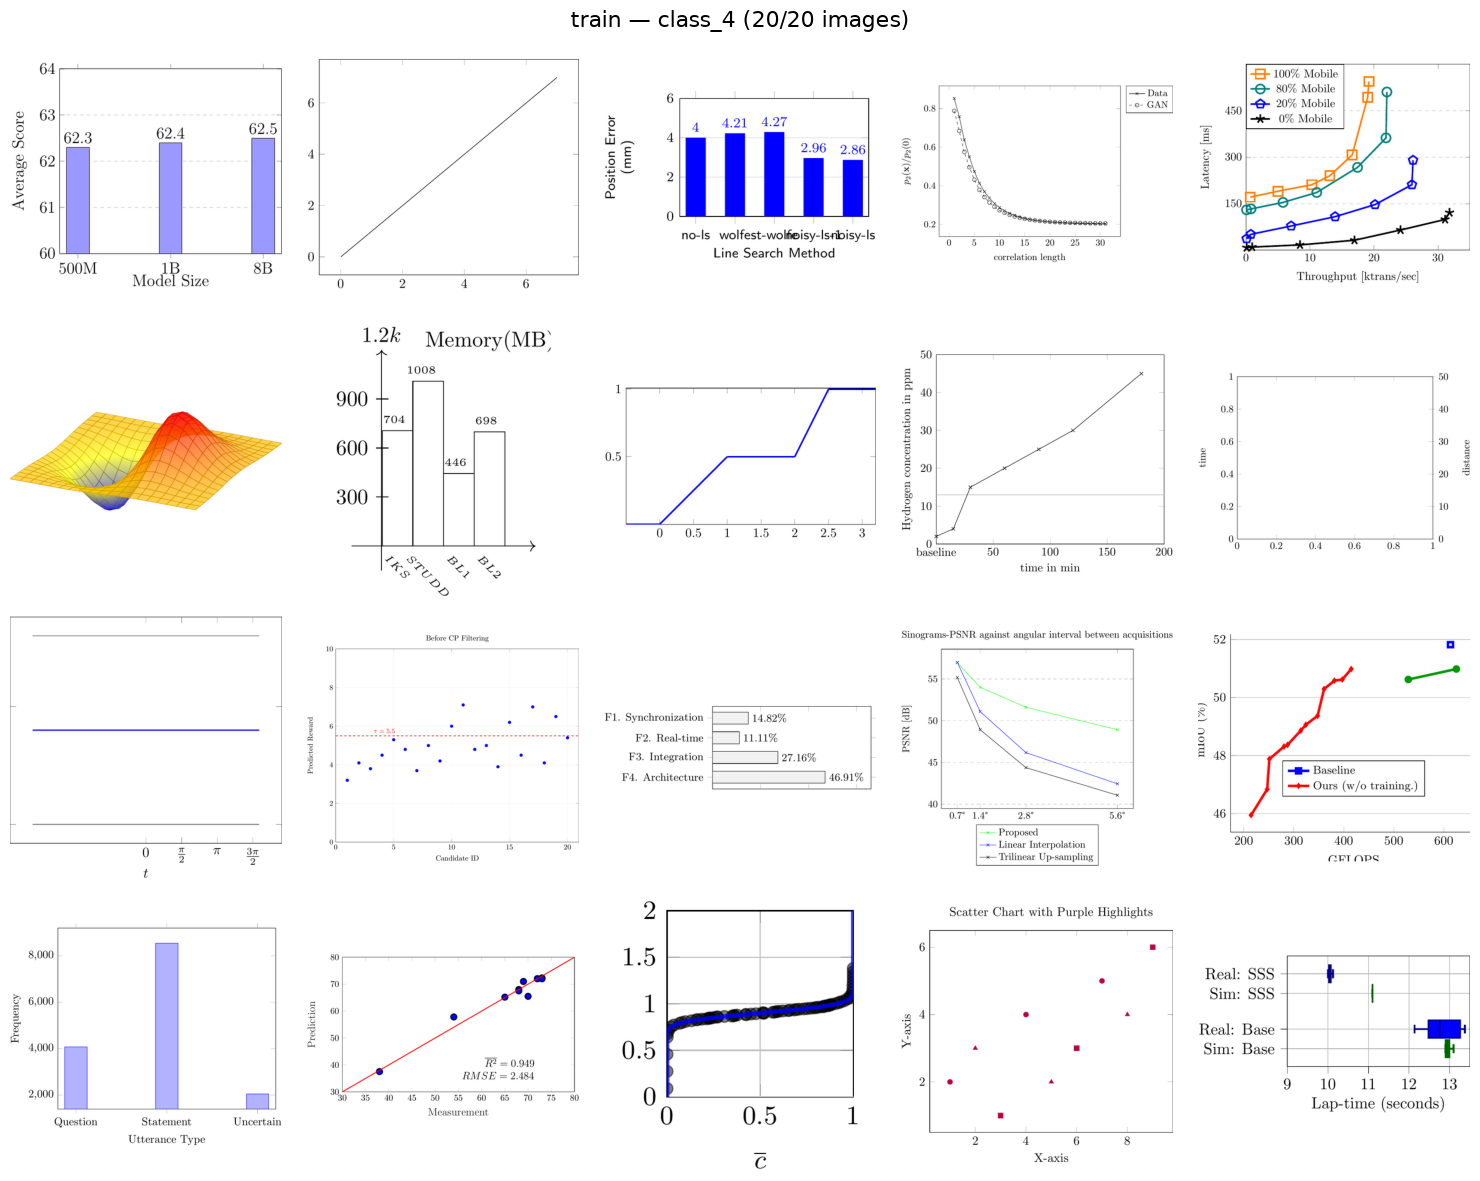

In [36]:
show_split_matrices("train")


## Benchmark matrices

This creates one matrix for every selected class in the `benchmark` split.


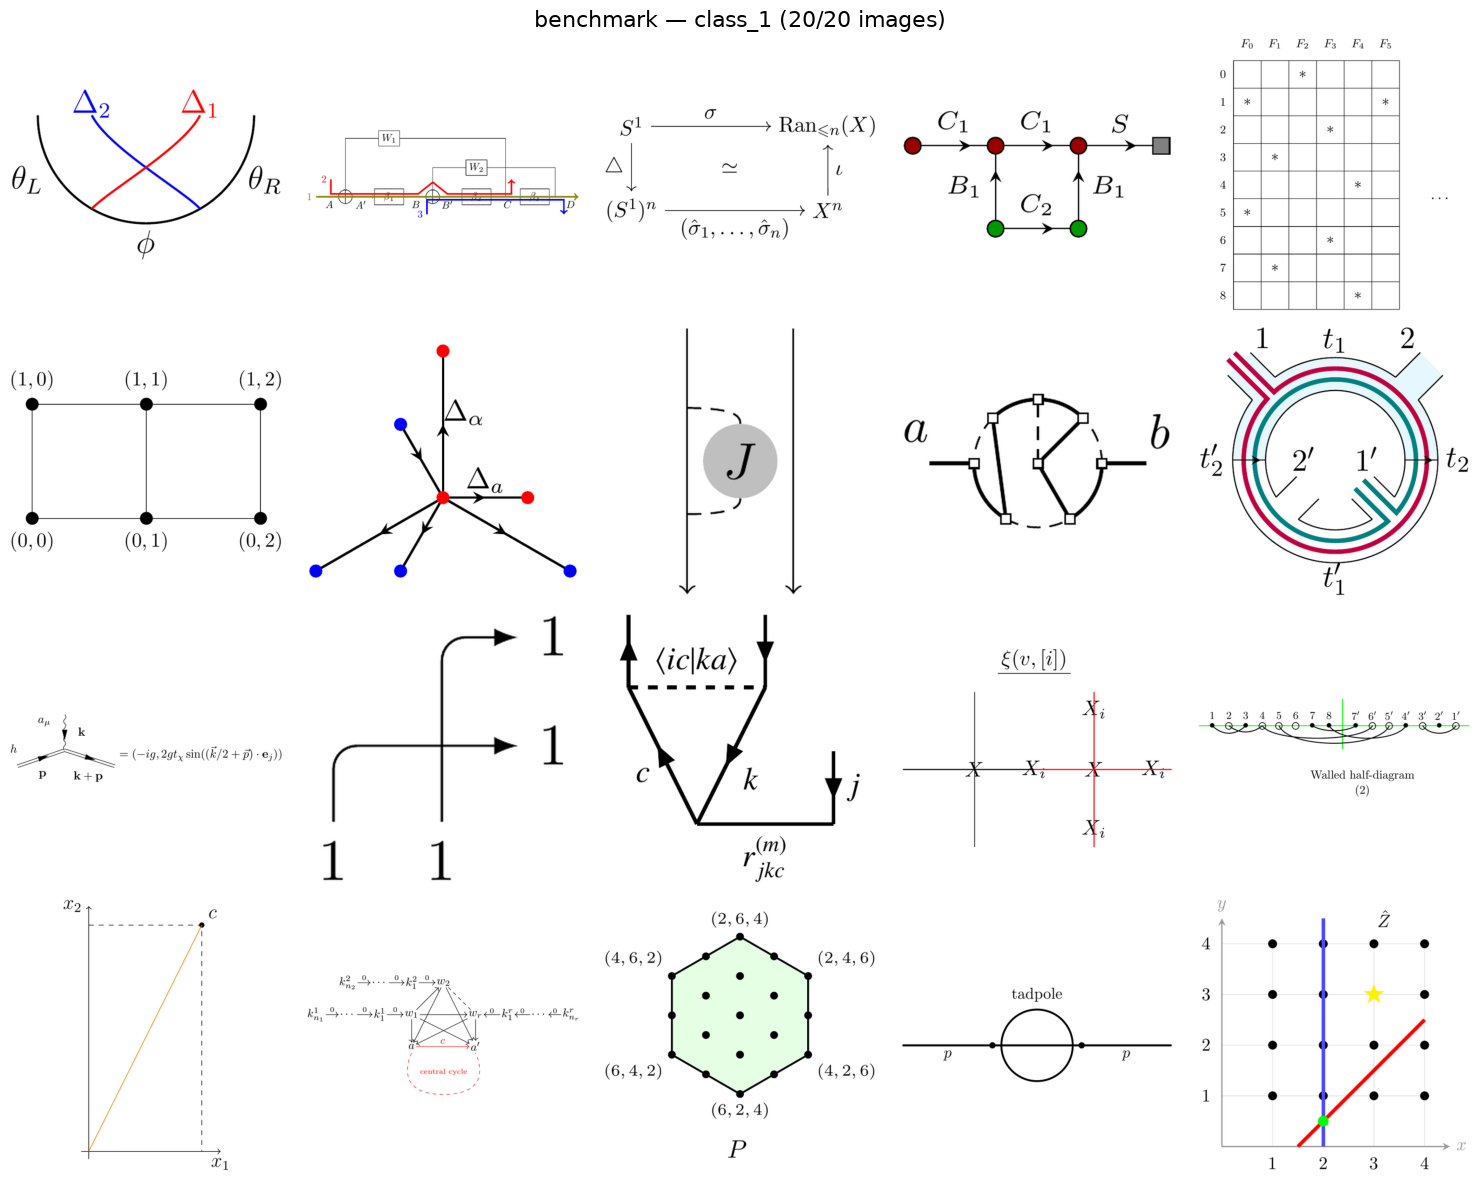

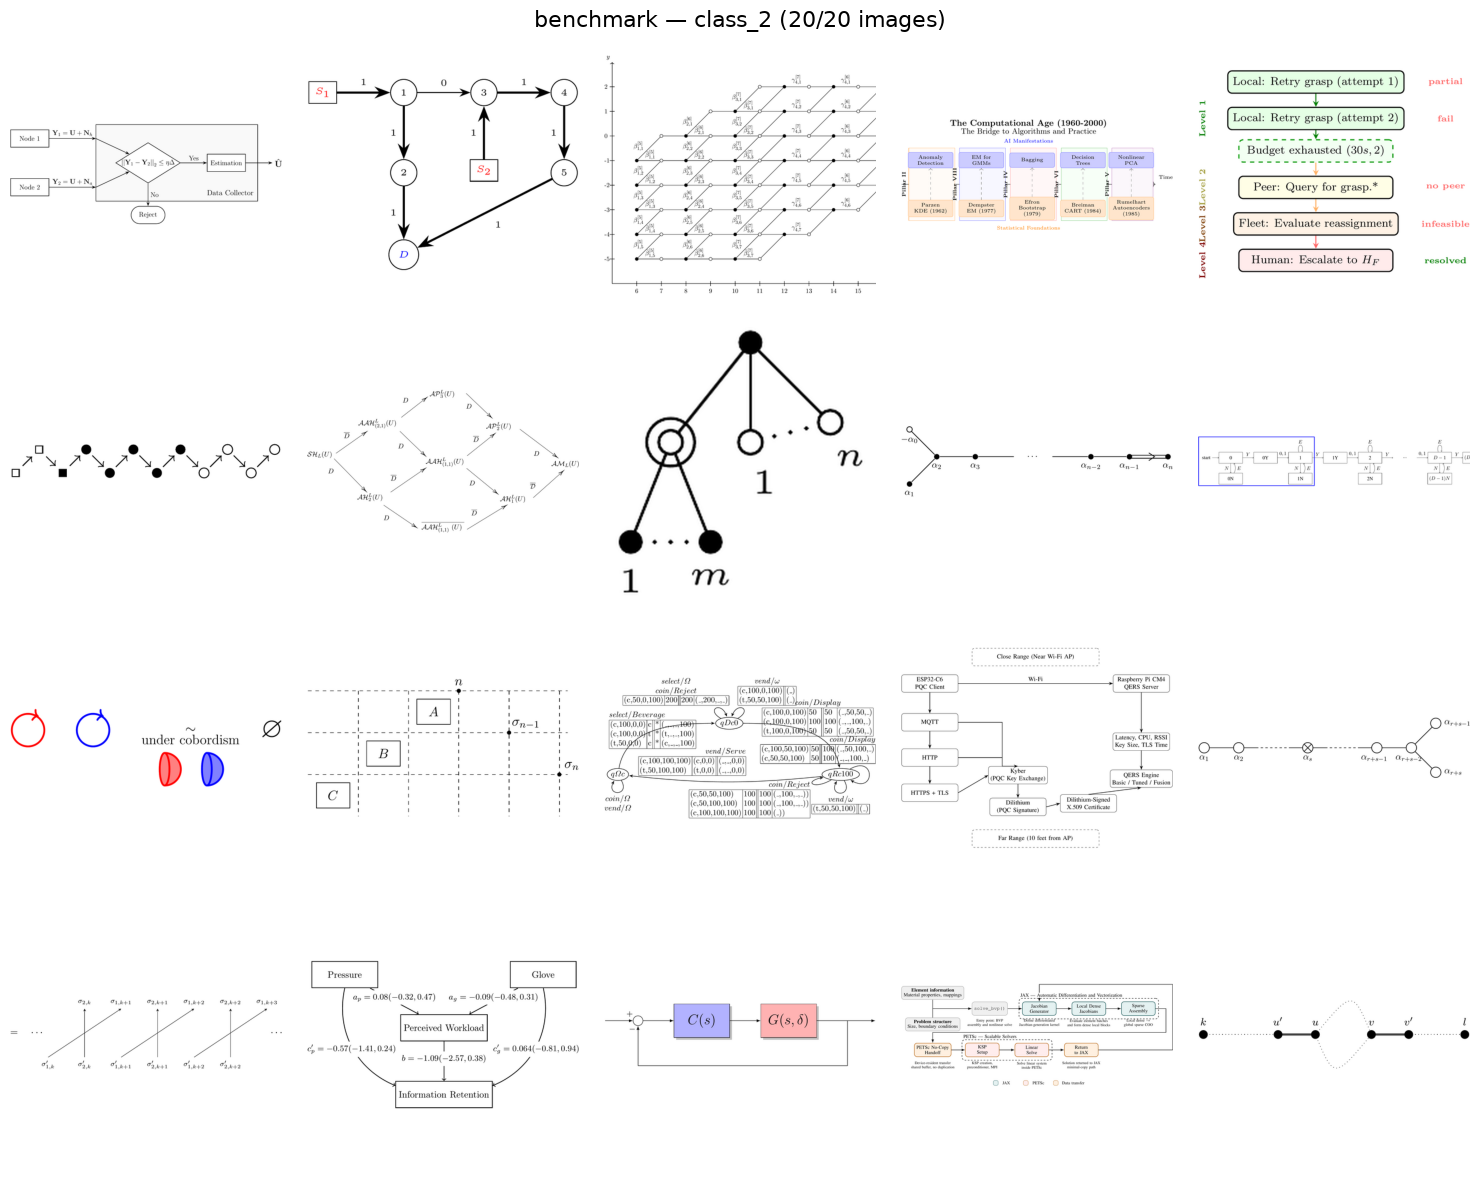

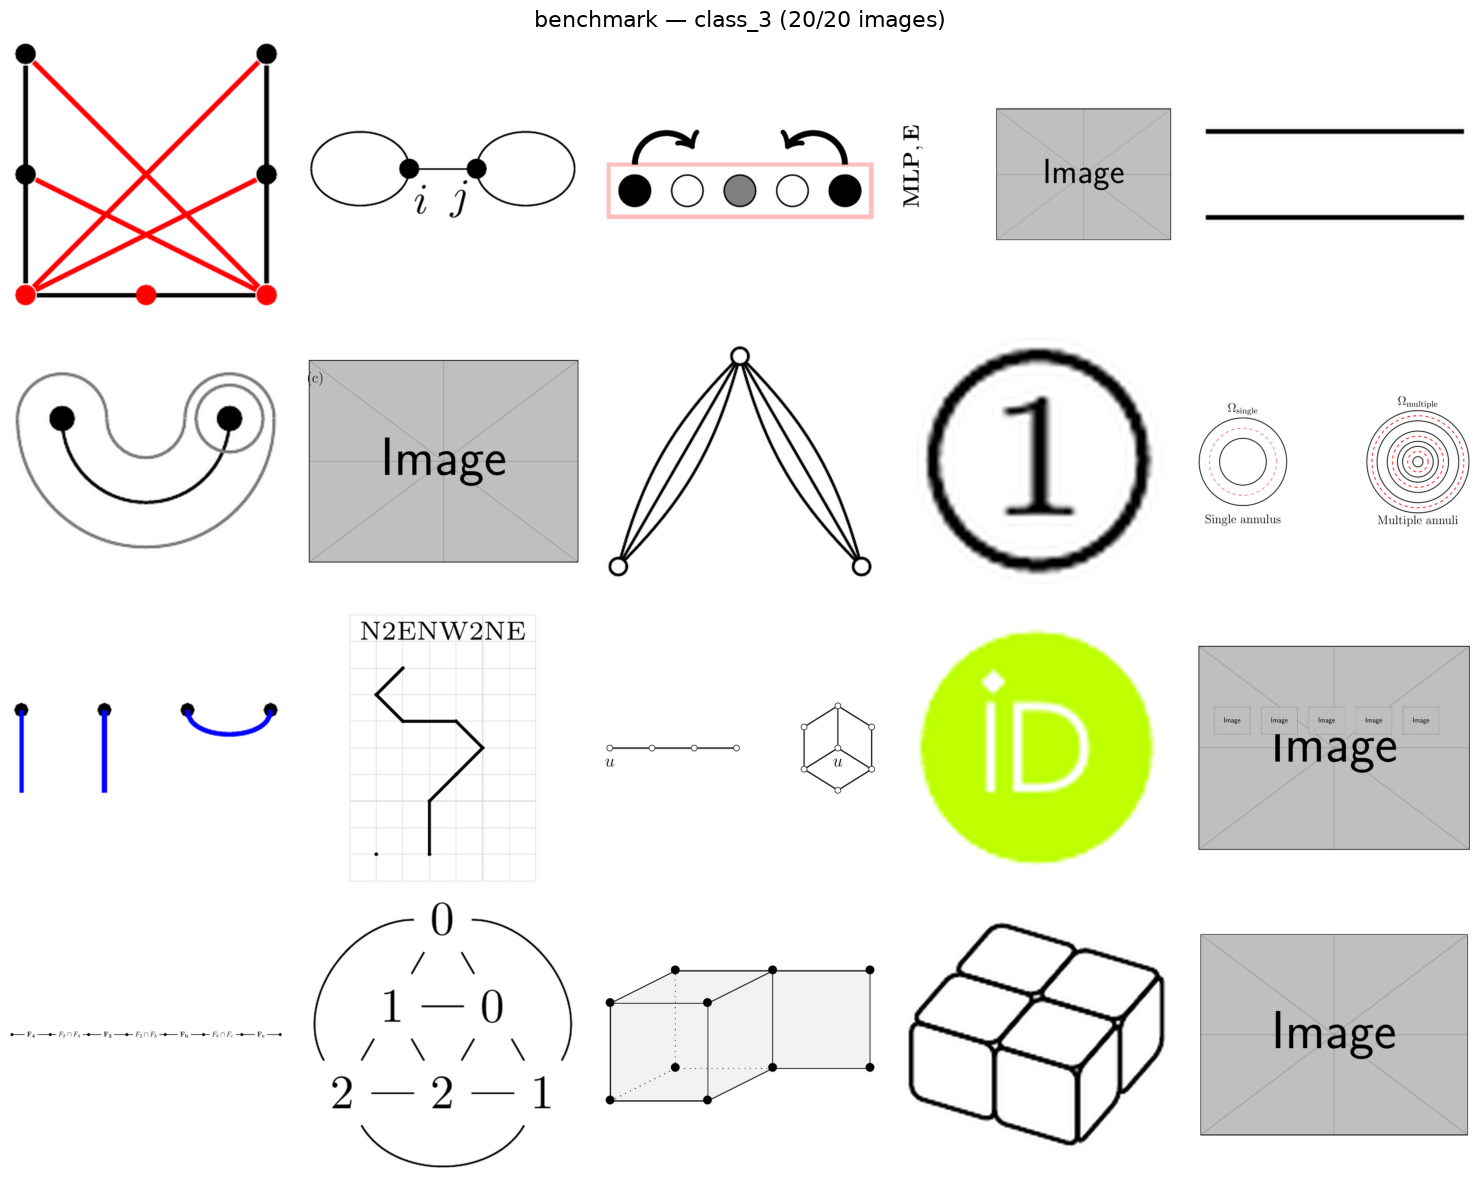

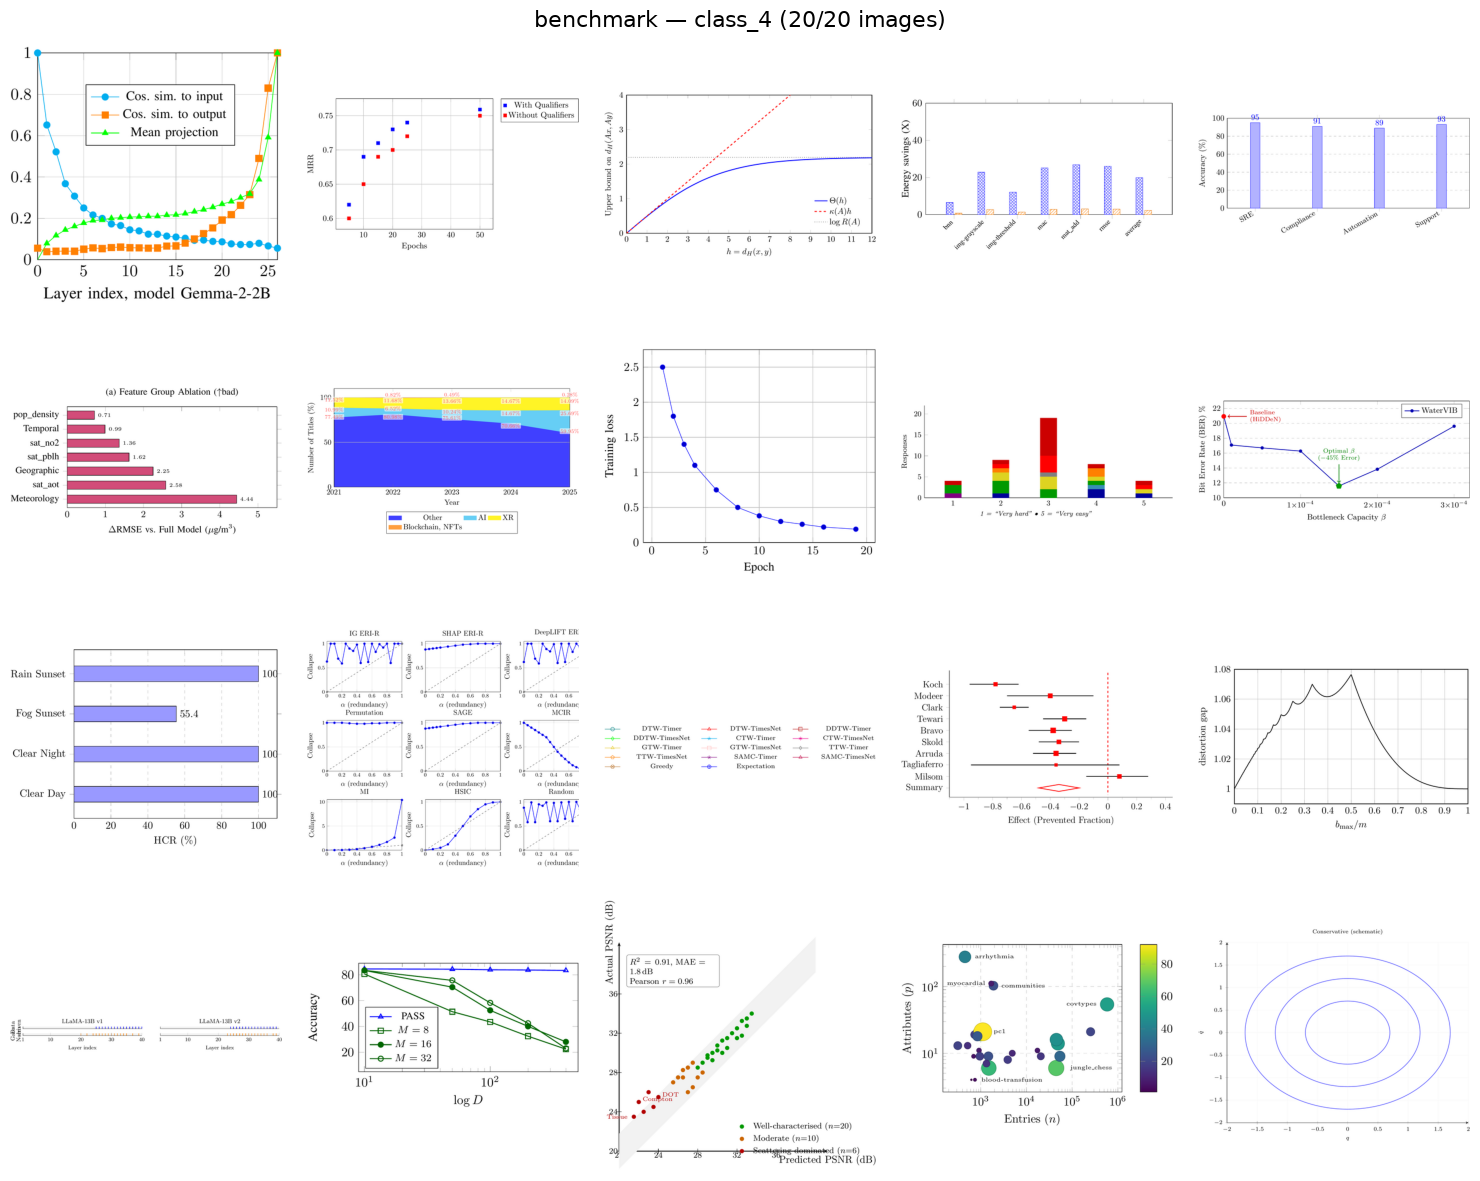

In [37]:
show_split_matrices("benchmark")


## Display one specific class

Use this when you only want to redraw one matrix.


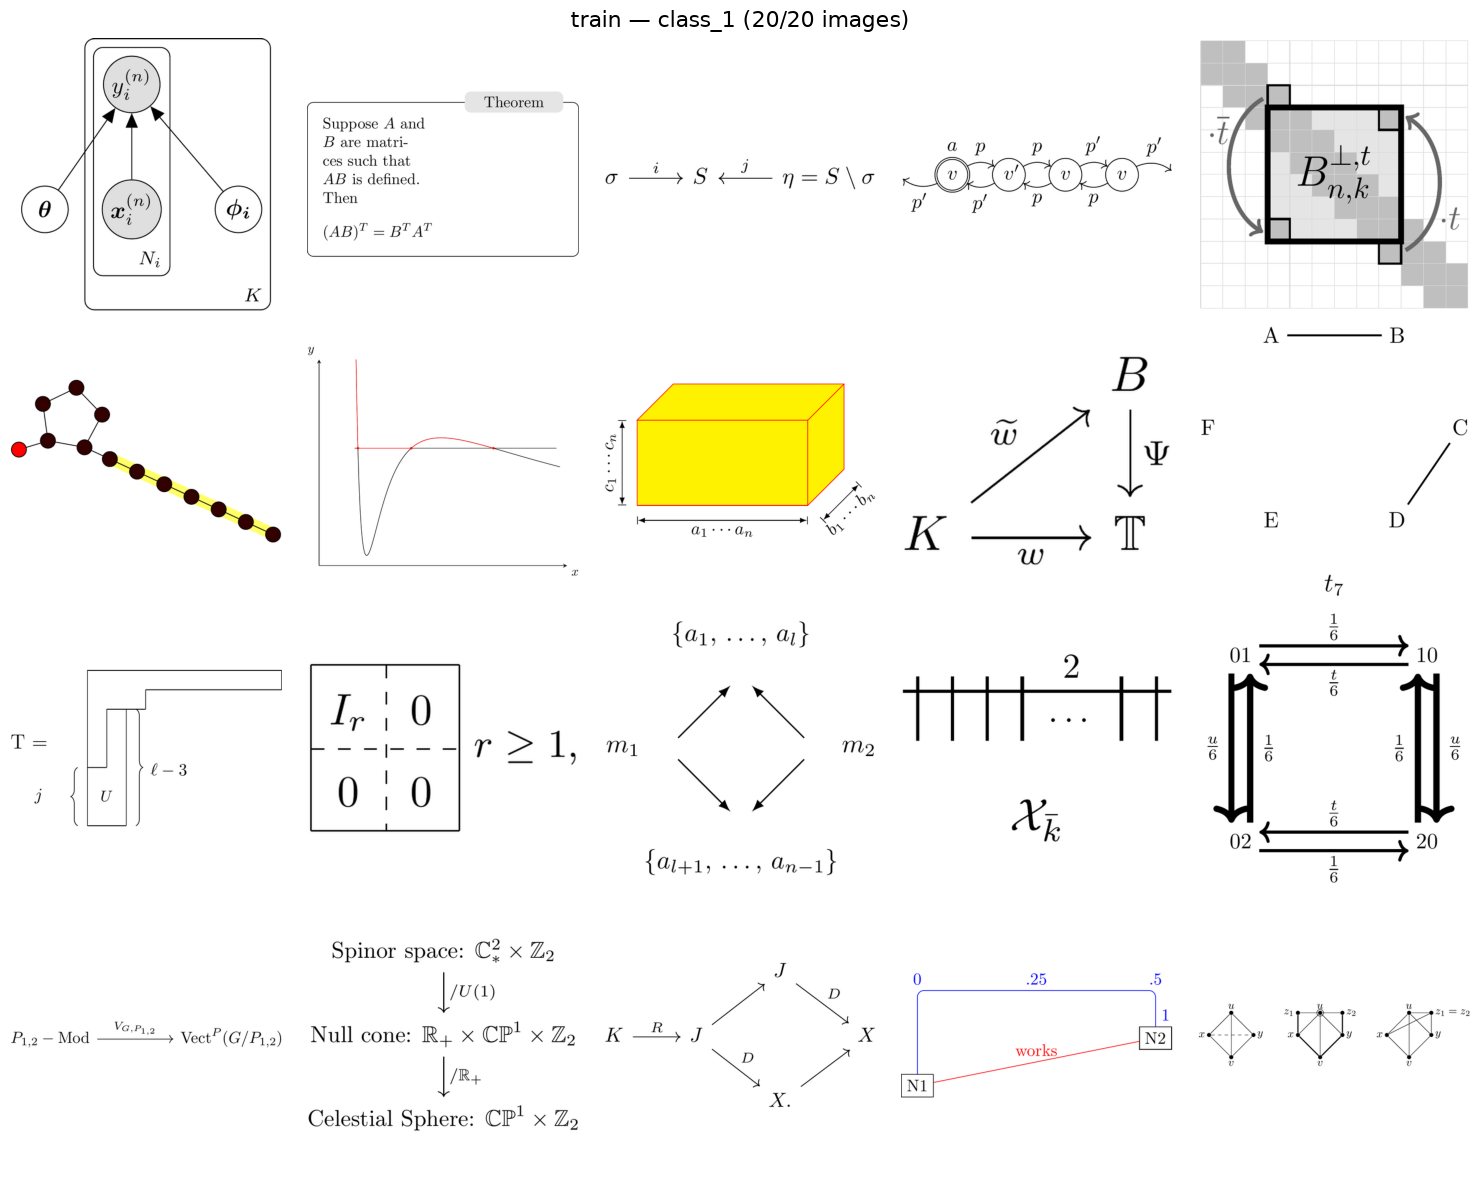

In [38]:
SPLIT_TO_SHOW = "train"
CLASS_TO_SHOW = "class_1"

show_class_matrix(
    SPLIT_TO_SHOW,
    CLASS_TO_SHOW,
)
